In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('train.csv')

In [4]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Working with Qualitative / Categorical Data

## a. Frequency Distribution Table

**Frequency** tells you how often something happened.  
The frequency of an observation tells you the number of times the observation occurs in the data.

### Example (Numerical Data)

Consider the following list of numbers:

1, 2, 3, 4, 6, 9, 9, 8, 5, 1, 1, 9, 9, 0, 6, 9


The frequency of the number **9** is **5**, because it appears **5 times** in the list.

---

### Example (Categorical Data)

The table below shows a **frequency distribution** for different education levels:

| Degree        | Frequency |
|--------------|-----------|
| High School  | 2         |
| Bachelor's   | 7         |
| MBA          | 20        |
| Master's     | 3         |
| Law          | 4         |
| PhD          | 4         |
| **Total**    | **40**    |

---

### Key Points
- Qualitative (categorical) data represents **labels or categories**
- Frequency tables summarize how often each category occurs
- The total frequency equals the total number of observations


In [5]:
data.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

# b. Bar Chart

<Axes: xlabel='Pclass'>

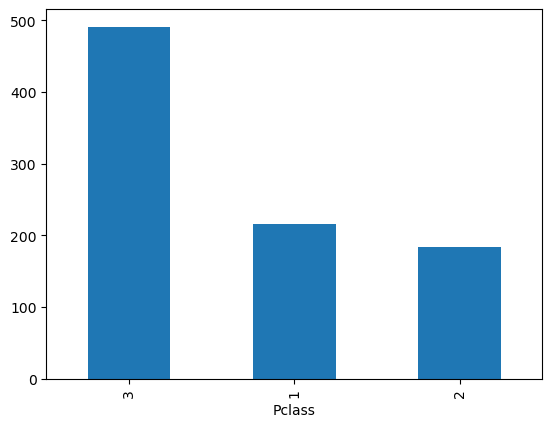

In [7]:
data['Pclass'].value_counts().plot(kind='bar')

# c. Pie Chart

<Axes: ylabel='count'>

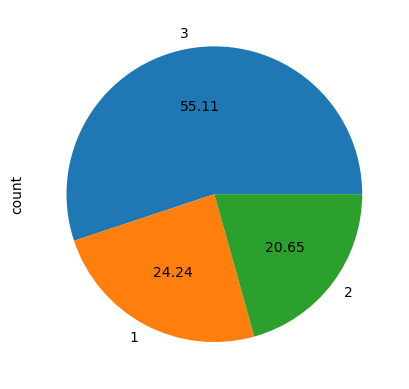

In [13]:
data['Pclass'].value_counts().plot(kind='pie',autopct='%0.2f')

## d. Cumulative Frequency

**Frequency** is the number of times an event occurs within a given scenario.

**Cumulative Frequency** is defined as the **running total of frequencies**.  
It is the sum of all previous frequencies up to the current point.

Cumulative frequency helps us understand how data accumulates over time or across values and is best explained using a **Cumulative Frequency Table**.

---

### Example

Consider the following **scores**:

1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 5
---

### Cumulative Frequency Table

| Score | Frequency | Cumulative Frequency |
|------:|----------:|---------------------:|
| 1     | 2         | 2                   |
| 2     | 5         | 7                   |
| 3     | 4         | 11                  |
| 4     | 2         | 13                  |
| 5     | 1         | 14                  |

---

### Explanation
- Cumulative frequency is obtained by **adding the current frequency to the previous cumulative frequency**
- The final cumulative frequency equals the **total number of observations**


In [17]:
a=data['Pclass'].value_counts()

In [19]:
(a/a.sum())*100

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64

In [20]:
b=((a/a.sum())*100).values

In [21]:
b

array([55.10662177, 24.24242424, 20.65095398])

In [22]:
c=[]
cf=0
for i in b:
    cf=cf+i
    c.append(cf)
    

In [24]:
c

[55.106621773288445, 79.34904601571269, 100.0]

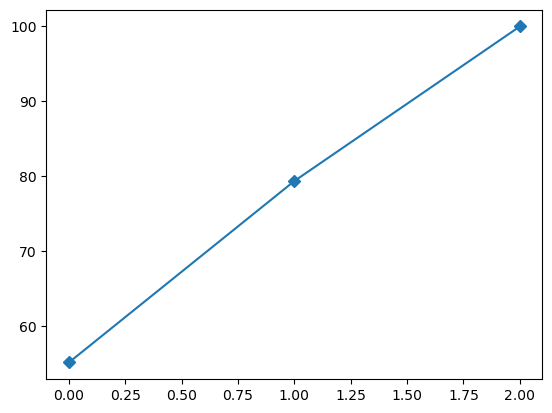

In [25]:
plt.plot(c,marker='D')

# 2. Working with Quantitative Data

## a. Histograms

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

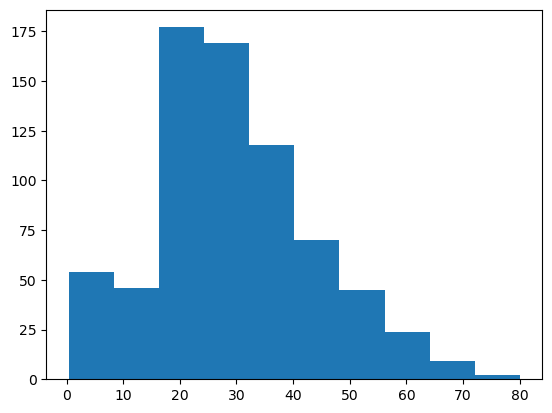

In [29]:
d=data['Age'].values
plt.hist(d)

## b. Boxplots

<Axes: xlabel='Age'>

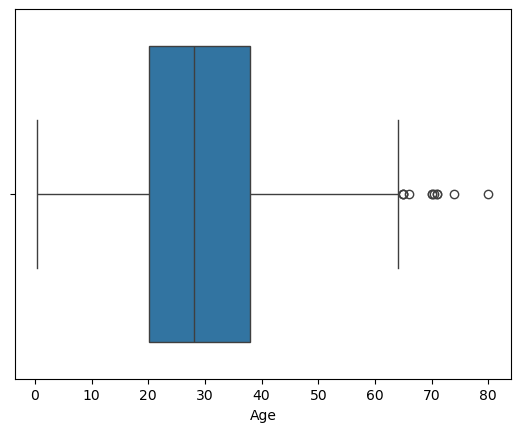

In [42]:
sns.boxplot(x=data['Age'])



In [39]:
a=data.dropna(subset=['Age'])
a=a['Age'].values
np.median(a)

28.0

## c. KdePlots

<Axes: xlabel='Age', ylabel='Density'>

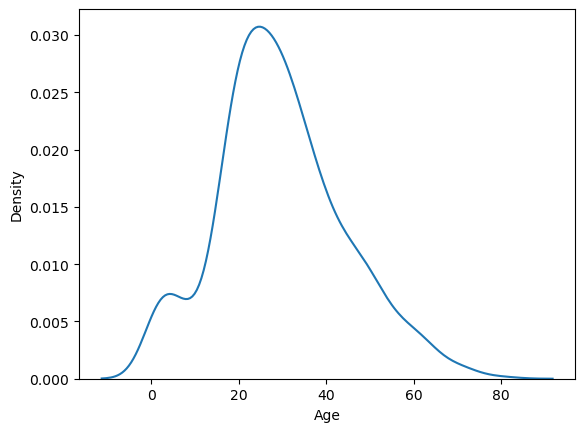

In [43]:
sns.kdeplot(data['Age'])

# Working with 2 Variables Bivariate Data

## 1. Categorical vs Numerical

### a. Box Plot

<Axes: xlabel='Pclass', ylabel='Age'>

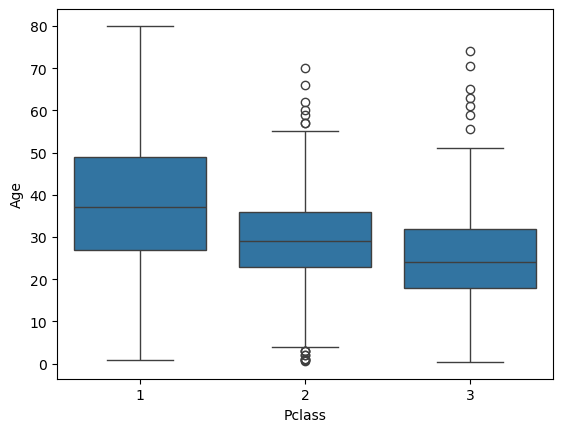

In [44]:
sns.boxplot(x='Pclass',y='Age',data=data)

### b. BarPlots

<Axes: xlabel='Pclass', ylabel='Age'>

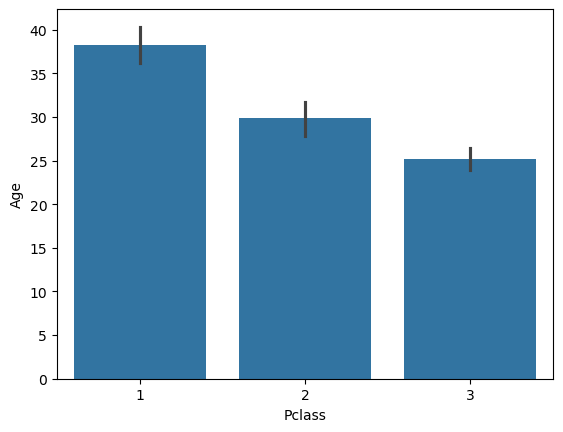

In [46]:
sns.barplot(x='Pclass',y='Age',data=data)

## 2. Numerical vs Numerical

### a. Scatter Plot

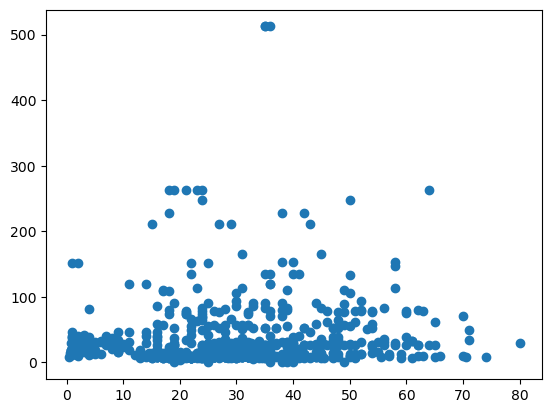

In [47]:
m=data['Age'].values
n=data['Fare'].values
plt.scatter(m,n)

# 3. Categorical vs Categorical Data

## a. Cross Tables / Contingency Table

In statistics, a **contingency table** (also known as a **cross tabulation** or **crosstab**) is a type of table in a matrix format that displays the **multivariate frequency distribution** of the variables.

It is used when **both variables are categorical**.

---

### Example: Class Rank vs Living on Campus

The table below shows a crosstabulation between **Class Rank** and whether students **live on campus**.

| Class Rank | Off-campus | On-campus | Total |
|-----------|------------|-----------|-------|
| Freshman  | 37         | 100       | 137   |
| Sophomore | 42         | 48        | 90    |
| Junior    | 90         | 8         | 98    |
| Senior    | 62         | 1         | 63    |
| **Total** | **231**    | **157**   | **388** |

---

### Key Points
- Both variables are **categorical**
- Each cell shows the **frequency (count)** of observations
- Marginal totals help compare distributions across categories
- Used heavily in **EDA**, **statistics**, and **ML preprocessing**


In [49]:
ct=pd.crosstab(data['Pclass'],data['Sex'])

<Axes: xlabel='Pclass'>

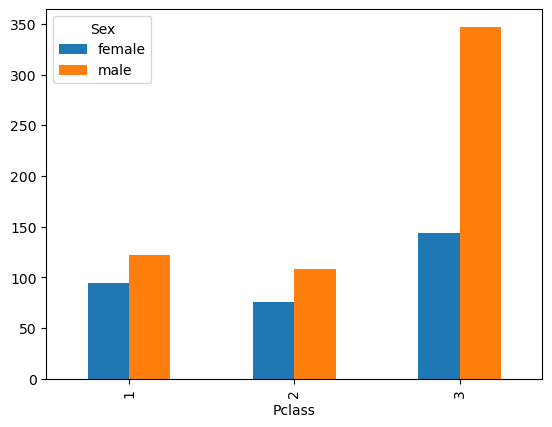

In [51]:
ct.plot(kind='bar')

### c. Heatmaps

<Axes: xlabel='Sex', ylabel='Pclass'>

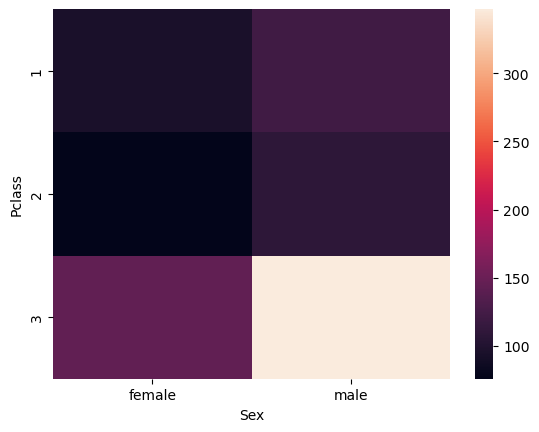

In [52]:
sns.heatmap((ct))